In [2]:
from pathlib import Path
import subprocess

# ===== 路径设置（相对项目根目录）=====
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    raise RuntimeError("未找到项目根目录 CIMA_multiomics_regulation，请在项目目录内运行该脚本。")

# ===== 核心路径 =====
PFILE_PREFIX = PROJECT_ROOT / "data/processed/genotype/CIMA_BGEID_metaMatched"
PHENO_FILE = PROJECT_ROOT / "data/processed/CIMA/phenotype/CIMA_metabolites_lipids_pheno_plink.tsv"
COVAR_FILE = PROJECT_ROOT / "data/processed/meta/CIMA_plink_covariates.tsv"
OUT_DIR = PROJECT_ROOT / "data/results/gwas_test_nopc"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PHENO_NAME = "Acesulfame"
OUT_PREFIX = OUT_DIR / f"test_{PHENO_NAME}"

# ===== 检查 pfile 三件套 =====
pgen = PFILE_PREFIX.with_suffix(".pgen")
pvar = PFILE_PREFIX.with_suffix(".pvar")
psam = PFILE_PREFIX.with_suffix(".psam")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PFILE_PREFIX =", PFILE_PREFIX)
print("PHENO_FILE   =", PHENO_FILE)
print("COVAR_FILE   =", COVAR_FILE)
print("OUT_PREFIX   =", OUT_PREFIX)

print("\n=== 文件存在性检查 ===")
for fp in [pgen, pvar, psam, PHENO_FILE, COVAR_FILE]:
    print(fp, fp.exists())
    if not fp.exists():
        raise FileNotFoundError(f"找不到: {fp}")

# ===== 输出文件 =====
GLM_FILE = OUT_DIR / f"test_{PHENO_NAME}.{PHENO_NAME}.glm.linear"
ADD_FILE = OUT_DIR / f"test_{PHENO_NAME}.{PHENO_NAME}.glm.linear.add"
SNPLIST_FILE = OUT_DIR / f"test_{PHENO_NAME}.snplist"
LOG_FILE = OUT_DIR / f"test_{PHENO_NAME}.log"

# ===== 1) 跑 plink2 =====

plink_cmd = [
    "plink2",
    "--pfile", str(PFILE_PREFIX),
    "--pheno", str(PHENO_FILE),
    "--maf", "0.05", # 371个样本建议甚至可以设为 0.1
    "--hwe", "1e-6",
    "--pheno-name", PHENO_NAME,
    "--pheno-quantile-normalize", # <--- 逆正态变换（Rank-Based Inverse Normal Transformation, INT）
    "--covar", str(COVAR_FILE),
    "--covar-name", "SEX,age,",# PC1", # ,PC2,PC3,PC4,PC5",#,PC6,PC7,PC8,PC9,PC10",
    "--glm", "hide-covar",
    "--write-snplist",
    "--threads", "8",
    "--memory", "30000",
    "--out", str(OUT_PREFIX),
]

print("\n=== running plink2 ===")
print(" ".join(plink_cmd))
subprocess.run(plink_cmd, check=True)

for fp in [GLM_FILE, SNPLIST_FILE, LOG_FILE]:
    if not fp.exists():
        raise FileNotFoundError(f"plink2 输出不存在: {fp}")

# ===== 2) 提取 TEST=ADD =====
# NR==1 保留表头
# 第10列通常是 TEST，但为了稳一点，先自动找 TEST 列号
awk_script = r'''BEGIN{FS=OFS="\t"}
NR==1{
    for(i=1;i<=NF;i++){
        if($i=="TEST"){
            test_col=i
        }
    }
    if(!test_col){
        print "ERROR: TEST column not found" > "/dev/stderr"
        exit 1
    }
    print
    next
}
$test_col=="ADD"{print}
'''

print("\n=== extracting ADD rows with awk ===")
with open(ADD_FILE, "w") as fout:
    subprocess.run(
        ["awk", awk_script, str(GLM_FILE)],
        stdout=fout,
        check=True,
        text=True
    )

print(f"saved: {ADD_FILE}")
print(f"saved: {SNPLIST_FILE}")

# ===== 3) 简单统计 =====
n_lines = sum(1 for _ in open(ADD_FILE)) - 1
n_snps = sum(1 for _ in open(SNPLIST_FILE))
print(f"ADD rows: {n_lines}")
print(f"snplist rows: {n_snps}")


PROJECT_ROOT = /data/work/CIMA_multiomics_regulation
PFILE_PREFIX = /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched
PHENO_FILE   = /data/work/CIMA_multiomics_regulation/data/processed/CIMA/phenotype/CIMA_metabolites_lipids_pheno_plink.tsv
COVAR_FILE   = /data/work/CIMA_multiomics_regulation/data/processed/meta/CIMA_plink_covariates.tsv
OUT_PREFIX   = /data/work/CIMA_multiomics_regulation/data/results/gwas_test_nopc/test_Acesulfame

=== 文件存在性检查 ===
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.pgen True
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.pvar True
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.psam True
/data/work/CIMA_multiomics_regulation/data/processed/CIMA/phenotype/CIMA_metabolites_lipids_pheno_plink.tsv True
/data/work/CIMA_multiomics_regulation/data/processed/meta/CIMA_plink_covariates.tsv True

=== running plink2 ===


## Manhattan 图

这一步读取 plink2 的 `.glm.linear` 结果，并且只保留：

- `TEST == ADD` 的结果
- `plink --write-snplist` 记录的实际分析 SNP

这样画图和 plink 实际参与分析的 SNP 集合一致，不再额外按 `A1_FREQ` 手动复刻 MAF 过滤。


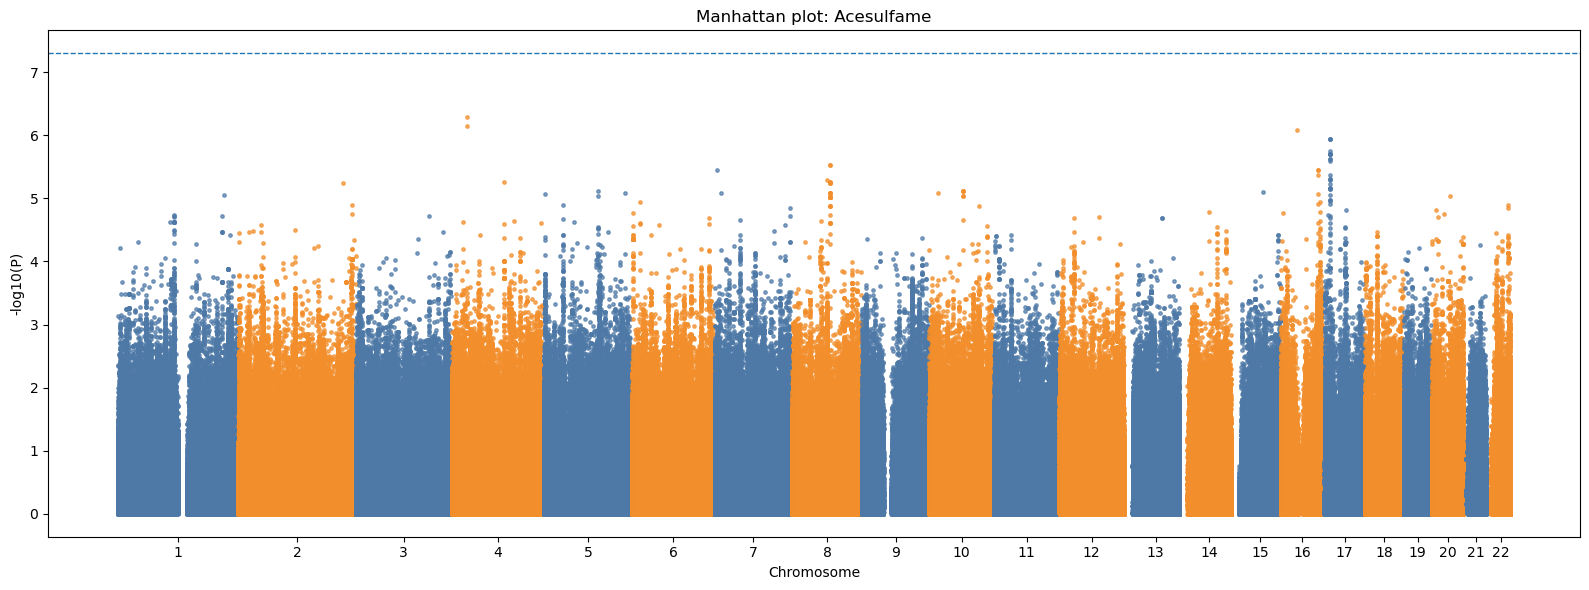

saved: /data/work/CIMA_multiomics_regulation/data/results/gwas_test_nopc/test_Acesulfame.manhattan.png
plot_df shape: (7372921, 6)


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_FILE = ADD_FILE
OUT_PNG = OUT_DIR / f"test_{PHENO_NAME}.manhattan.png"

# 读取实际分析 SNP 列表
snplist = set(pd.read_csv(SNPLIST_FILE, header=None)[0])

# 只读必要列
plot_df = pd.read_csv(
    RESULT_FILE,
    sep="\t",
    usecols=["#CHROM", "POS", "ID", "P"]
)

# 只保留 plink 实际分析 SNP
plot_df = plot_df[plot_df["ID"].isin(snplist)].copy()

# 类型转换
plot_df["P"] = pd.to_numeric(plot_df["P"], errors="coerce")
plot_df["POS"] = pd.to_numeric(plot_df["POS"], errors="coerce")

# 染色体整理
plot_df["#CHROM"] = plot_df["#CHROM"].astype(str).str.replace("^chr", "", regex=True)
plot_df = plot_df[plot_df["#CHROM"].isin([str(i) for i in range(1, 23)] + ["X"])]
plot_df["#CHROM"] = plot_df["#CHROM"].replace({"X": "23"}).astype(int)

# 基本过滤
plot_df = plot_df.dropna(subset=["#CHROM", "POS", "P"])
plot_df = plot_df[(plot_df["P"] > 0) & (plot_df["P"] <= 1)].copy()

# 计算 -log10(P)
plot_df["minus_log10_p"] = -np.log10(plot_df["P"])

# 排序
plot_df = plot_df.sort_values(["#CHROM", "POS"]).reset_index(drop=True)

# 计算 cumulative BP
chr_max = plot_df.groupby("#CHROM", sort=True)["POS"].max()
chr_offset = chr_max.cumsum().shift(fill_value=0).to_dict()
plot_df["BP_cum"] = plot_df["POS"] + plot_df["#CHROM"].map(chr_offset)

# 每条染色体中心位置
chr_center = plot_df.groupby("#CHROM", sort=True)["BP_cum"].agg(["min", "max"])
chr_center["center"] = (chr_center["min"] + chr_center["max"]) / 2

# 画图
plt.figure(figsize=(16, 6))
colors = ["#4E79A7", "#F28E2B"]
for i, (chrom, sub) in enumerate(plot_df.groupby("#CHROM", sort=True)):
    plt.scatter(sub["BP_cum"], sub["minus_log10_p"], s=6, alpha=0.7, color=colors[i % 2])

plt.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)
plt.xticks(chr_center["center"], [str(c) if c != 23 else "X" for c in chr_center.index])
plt.xlabel("Chromosome")
plt.ylabel("-log10(P)")
plt.title(f"Manhattan plot: {PHENO_NAME}")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

print("saved:", OUT_PNG)
print("plot_df shape:", plot_df.shape)

valid P: 7372921


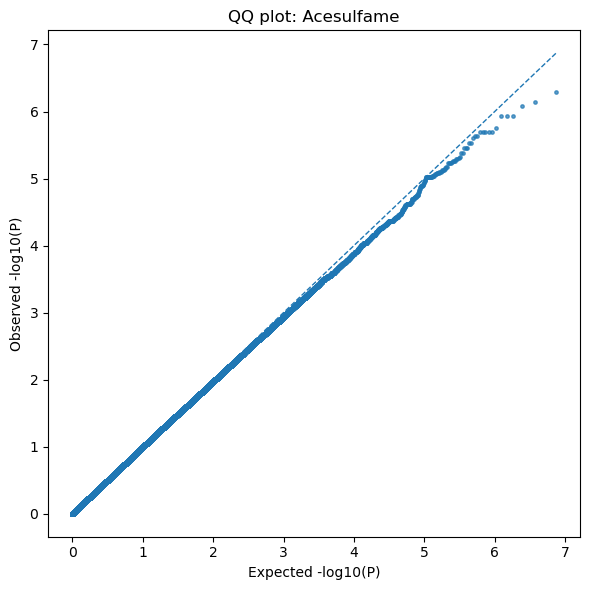

saved: /data/work/CIMA_multiomics_regulation/data/results/gwas_test_nopc/test_Acesulfame.qq.png


ModuleNotFoundError: No module named 'scipy'

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_FILE = ADD_FILE
OUT_PNG = OUT_DIR / f"test_{PHENO_NAME}.qq.png"

# ===== 读取数据 =====
plot_df = pd.read_csv(
    RESULT_FILE,
    sep="\t",
    usecols=["P"]
)

# 类型转换 + 过滤
plot_df["P"] = pd.to_numeric(plot_df["P"], errors="coerce")
plot_df = plot_df[(plot_df["P"] > 0) & (plot_df["P"] <= 1)].dropna()

print("valid P:", plot_df.shape[0])

# ===== QQ plot =====
pvals = plot_df["P"].values

# observed
obs = -np.log10(np.sort(pvals))

# expected
exp = -np.log10(np.linspace(1/len(pvals), 1, len(pvals)))

# ===== 画图 =====
plt.figure(figsize=(6,6))
plt.scatter(exp, obs, s=6, alpha=0.7)

# 对角线
max_val = max(exp.max(), obs.max())
plt.plot([0, max_val], [0, max_val], linestyle="--", linewidth=1)

plt.xlabel("Expected -log10(P)")
plt.ylabel("Observed -log10(P)")
plt.title(f"QQ plot: {PHENO_NAME}")

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150)
plt.show()

print("saved:", OUT_PNG)
from scipy.stats import chi2

chi2_vals = chi2.isf(plot_df["P"], df=1)
lambda_gc = np.median(chi2_vals) / chi2.ppf(0.5, df=1)

print("lambda_GC:", round(lambda_gc, 3))